# Stanford CME 241 (Winter 2026) - Assignment 2

**Due: Friday, February 13 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/my-username/my-repo/assignment-file-name.ipynb

*Group members (replace below names with people in your group):* 
- Person 1
- Person 2
- Person 3

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import itertools
from dataclasses import dataclass
from typing import Dict, Mapping, Tuple
from rl.markov_decision_process import FiniteMarkovDecisionProcess
from rl.distribution import Categorical
from scipy.stats import poisson

from rl.dynamic_programming import value_iteration_result
from pprint import pprint

## Question 1: Job-Hopping and Wages-Utility-Maximization (Led by ______)

You are a worker who starts every day either employed or unemployed. If you start your day employed, you work on your job for the day (one of $n$ jobs, as elaborated later) and you get to earn the wage of the job for the day. However, at the end of the day, you could lose your job with probability $\alpha \in [0,1]$, in which case you start the next day unemployed. If at the end of the day, you do not lose your job (with probability $1-\alpha$), then you will start the next day with the same job (and hence, the same daily wage). 

On the other hand, if you start your day unemployed, then you will be randomly offered one of $n$ jobs with daily wages $w_1, w_2, \ldots w_n \in \mathbb{R}^+$ with respective job-offer probabilities $p_1, p_2, \ldots p_n \in [0,1]$ (with $\sum_{i=1}^n p_i = 1$). You can choose to either accept or decline the offered job. If you accept the job offer, your day progresses exactly like the **employed-day** described above (earning the day's job wage and possibly (with probability $\alpha$) losing the job at the end of the day). However, if you decline the job offer, you spend the day unemployed, receive the unemployment wage $w_0 \in \mathbb{R}^+$ for the day, and start the next day unemployed.

The problem is to identify the optimal choice of accepting or rejecting any of the job offers the worker receives, in a manner that maximizes the infinite-horizon **Expected Discounted-Sum of Wages Utility**. Assume the daily discount factor for wages (employed or unemployed) is $\gamma \in [0,1])$. Assume Wages Utility function to be $U(w) = \log(w)$ for any wage amount $w \in \mathbb{R}^+$. The goal is to maximize:

$$
\mathbb{E}\left[\sum_{u=t}^\infty \gamma^{u-t} \cdot \log(w_{i_u})\right]
$$

at the start of a given day $t$ ($w_{i_u}$ is the wage earned on day $u$, $0 \leq i_u \leq n$ for all $u \geq t$).

---

### Subquestions

#### Part (A): MDP Modeling

Express the job-hopping problem as an MDP using clear mathematical notation by defining the following components:

1. **State Space**: Define the possible states of the MDP.
2. **Action Space**: Specify the actions available to the worker at each state.
3. **Transition Function**: Describe the probabilities of transitioning between states for each action.
4. **Reward Function**: Specify the reward associated with the states and transitions.
5. **Bellman Optimality Equation**: Write the Bellman Optimality Equation customized for this MDP.

---

#### Part (B): Python Implementation

Write Python code that:

1. Solves the Bellman Optimality Equation (hence, solves for the **Optimal Value Function** and the **Optimal Policy**) with a numerical iterative algorithm. 
2. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

*Note*: For this problem, write the algorithm from scratch without using any prebuilt MDP/DP libraries or code.

---

#### Part (C): Visualization and Analysis

1. Plot the **Optimal Value Function** as a function of the state for a specific set of parameters ($n$, $w_1, \ldots, w_n$, $p_1, \ldots, p_n$, $\alpha$, $\gamma$, $w_0$).
2. Include these graphs in your submission.

---

#### Part (D): Observations

1. What patterns do you observe in the **Optimal Policy** as you vary the parameters $n$, $\alpha$, and $\gamma$?
2. Provide a brief discussion of your findings.

---

### Part (A) Answer
**State space**:
$S = \{s_0, ..., s_n\}$ where $s_0$ is the unemployed state and $s_i, 1\leq i \leq n$ is the state of being in job $i$.
There are no terminal states.

**Action space**
$A=\{0, 1\}$ where $1$ indicates accept offer and $0$ indicates decline offer. In other states than $s_0$ the action is not meaningful.

**Transition Function**
The state transtition function can be expressed as follows:
$$
\begin{align*}
P(s, a, s') = \begin{cases}
P(s_0, 0, s_0) = 1\\
P(s_0, 1, s_0) = \sum_{i=1}^{n}p_i\alpha = \alpha \\
P(s_0, 1, s_i) = p_i(1-\alpha), \quad &1\leq i\leq n\\
P(s_i, 0, s_0) = \alpha, \quad &1\leq i\leq n\\
P(s_i, 1, s_0) = \alpha, \quad &1\leq i\leq n\\ 
P(s_i, 0, s_i) = 1-\alpha, \quad &1\leq i\leq n\\ 
P(s_i, 1, s_i) = 1-\alpha, \quad &1\leq i\leq n\\
0, \text{ otherwise}
\end{cases}
\end{align*}
$$

**Reward function**
The reward transition function can be expressed as follows:
$$
\begin{align*}
R_T(s, a, s') = 
\begin{cases}
R_T(s_0, 0, s_0) = \log(w_0)\\
R_T(s_0, 1, s_0) = \sum_{i=1}^{n} p_i\log(w_i)\\
R_T(s_i, a, s_i) = \log(w_i), \quad &1\leq i\leq n, \forall a\in A\\
R_T(s_i, a, s_0) = \log(w_i), \quad &1\leq i\leq n, \forall a\in A\\
\end{cases}
\end{align*}
$$

From class we have that the MDP State-Value Function Bellman Optimality Equation is given by:
$$
V^*(s)=\max_{a\in A} \{R(s,a)+ \gamma\sum_{s'\in N} P(s, a, s')V^*(s') \}
$$

For the states $s_i$ where $1\leq i\leq n$ we have:
$$
\begin{align*}
V^*(s_i) &= \log(w_i) + \gamma((1-\alpha)V^*(s_i) + \alpha V^*(s_0))\\
V^*(s_i)(1- \gamma(1-\alpha)) &= \log(w_i) + \gamma\alpha V^*(s_0)\\
V^*(s_i) &= \frac{\log(w_i) + \gamma\alpha V^*(s_0)}{1- \gamma(1-\alpha)}\\
\end{align*}
$$
For the state $s_0$ we get a slightly more complicated expression:

$$
\begin{align*}
V^*(s_0)=\sum_{i=1}^{n}p_i\max\{\log(w_0)+\gamma V^*(s_0), \log(w_i) + \gamma(\alpha V^*(s_0) + (1-\alpha)V^*(s_i))\}
\end{align*}
$$
Where the first term corresponds to declining the offer, and the second term corresponds to accepting the offer.



### Part (B) Answer

In [2]:
# fill in with Python code
from typing import List, Tuple, Optional
def job_hopping_mdp(
        n: int,
        w: List[float],
        p: List[float],
        alpha: float,
        gamma: float,
        tol: Optional[float] = 1e-8,
        max_iters: Optional[int] = 10_000
):
    """
    Function for solving job hopping mdp
    
    Args:
        p (List[float]): list of n probabilities.
        w (List[float]): list of n+1 wages.
        gamma (float): discount factor.
        alpha (float): probability of loosing job.

    Returns:
        Tuple[List[float], List[integer]]: returns a tuple of value function and optimal policy.
    """
    assert n == len(p), 'Length of p must be n.'
    assert n + 1 == len(w), 'Length of w must be n+1 (include the wage of unemployed).'
    assert np.all(np.array(w) > 0), 'Wages must be nonnegative.'
    assert gamma >= 0 and gamma <= 1, 'Discount factor must be between 0 and 1.'
    assert alpha >= 0 and alpha <= 1, 'Probability of loosing job must be between 0 and 1.'
    assert sum(p) == 1, 'Probabilities must sum to one.'

    p, w = np.array(p), np.array(w)
    v, policy = np.zeros(n+1, dtype=float), np.zeros(n, dtype=float)
    
    for i in range(max_iters):
        v_old = v.copy()

        # v_0 = [
        #     np.log(w[0] + gamma*v_old[0]),
        #     np.sum(p*np.log(w[1:n+1])) + gamma*np.sum( p*((1-alpha)*v_old[1:n+1]+alpha*v_old[0]) )
        # ]

        v0 = 0
        for i in range(n):
            v0_j_vals = [
                np.log(w[0])+ gamma*v_old[0],
                np.log(w[i+1]) + gamma*(alpha*v_old[0] + (1-alpha)*v_old[i+1])
            ]
            v0_j = p[i]*np.max(v0_j_vals)
            v0 += v0_j
            policy[i] = np.argmax(v0_j_vals)

        v[0] = v0

        for i in range(1, n+1):
            v[i] = (np.log(w[i]) + gamma*alpha*v_old[0]) / (1-gamma*(1-alpha))
        deltas = abs(v-v_old)

        if np.all(deltas <= tol):
            break
        
        
    return v, policy

### Part (C) Answer

<span style="color:red">*fill in*</span>

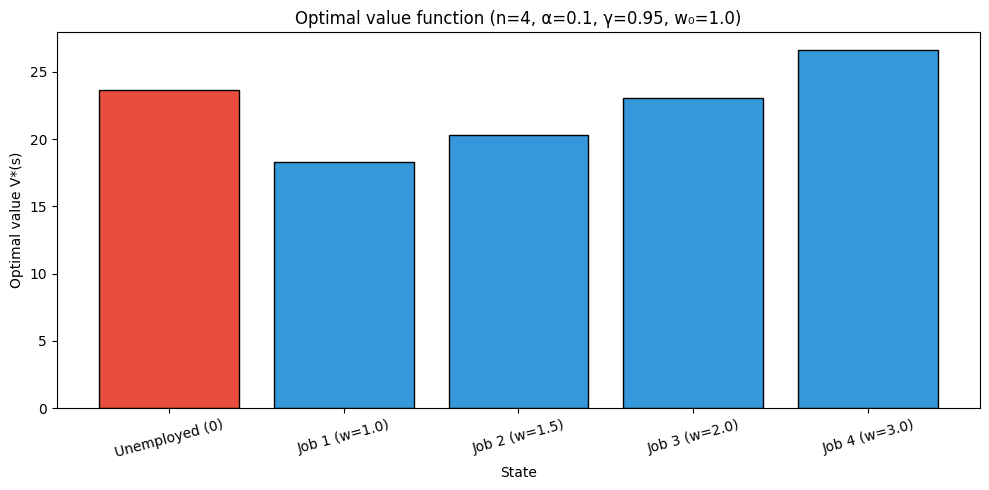

Optimal policy when unemployed: accept job j (1-indexed) iff accept_offer[j-1] is True: [0. 0. 1. 1.]


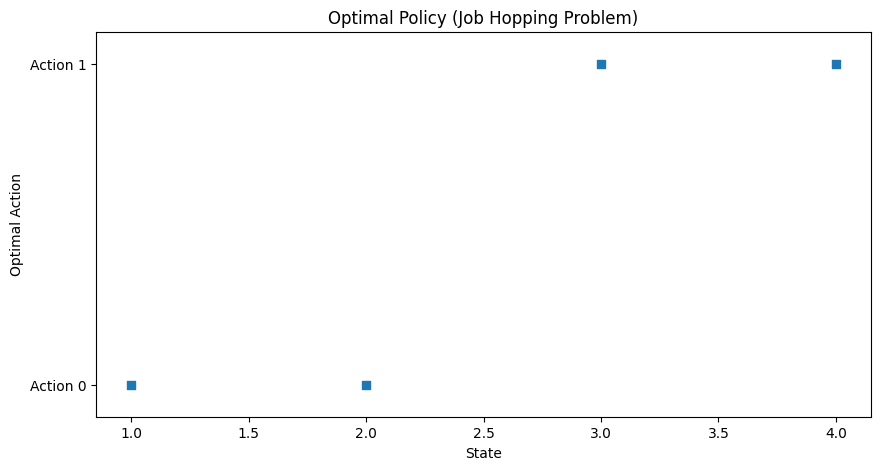

In [3]:
# Example: run solver and plot optimal value function (Part C)
n = 4
w = [1.0, 1.5, 2.0, 3.0, 5.0]   # wages for jobs 0..n
p = [0.25, 0.25, 0.25, 0.25]
alpha = 0.1
gamma = 0.95

V, accept_offer = job_hopping_mdp(n, w, p, alpha, gamma)
states = list(range(n + 1))
labels = ['Unemployed (0)'] + [f'Job {i} (w={w[i-1]})' for i in range(1, n + 1)]

plt.figure(figsize=(10, 5))
plt.bar(states, V, color=['#e74c3c'] + ['#3498db'] * n, edgecolor='black')
plt.xticks(states, labels, rotation=15)
plt.xlabel('State')
plt.ylabel('Optimal value V*(s)')
plt.title(f'Optimal value function (n={n}, α={alpha}, γ={gamma}, w₀={w[0]})')
plt.tight_layout()
plt.show()

print('Optimal policy when unemployed: accept job j (1-indexed) iff accept_offer[j-1] is True:', accept_offer)
plt.figure(figsize=(10, 5))
plt.scatter(states[1:], accept_offer, marker="s")
plt.yticks([0, 1], ['Action 0', 'Action 1'])
plt.xlabel('State')
plt.ylabel('Optimal Action')
plt.title('Optimal Policy (Job Hopping Problem)')
plt.ylim(-0.1, 1.1)
plt.show()

### Part (D) Answer

<span style="color:red">*fill in*</span>

## Question 2: Two-Stores Inventory Control (Led by ______)

We extend the capacity-constrained inventory example implemented in [rl/chapter3/simple_inventory_mdp_cap.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/chapter3/simple_inventory_mdp_cap.py) as a `FiniteMarkovDecisionProcess` (the Finite MDP model for the capacity-constrained inventory example is described in detail in Chapters 1 and 2 of the RLForFinanceBook). Here we assume that we have two different stores, each with their own separate capacities $C_1$ and $C_2$, their own separate Poisson probability distributions of demand (with means $\lambda_1$ and $\lambda_2$), their own separate holding costs $h_1$ and $h_2$, and their own separate stockout costs $p_1$ and $p_2$. At 6pm upon stores closing each evening, each store can choose to order inventory from a common supplier (as usual, ordered inventory will arrive at the store 36 hours later). We are also allowed to transfer inventory from one store to another, and any such transfer happens overnight, i.e., will arrive by 6am next morning (since the stores are fairly close to each other). Note that the orders are constrained such that following the orders on each evening, each store's inventory position (sum of on-hand inventory and on-order inventory) cannot exceed the store's capacity (this means the action space is constrained to be finite). Each order made to the supplier incurs a fixed transportation cost of $K_1$ (fixed-cost means the cost is the same no matter how many units of non-zero inventory a particular store orders). Moving any non-zero inventory between the two stores incurs a fixed transportation cost of $K_2$. 

Model this as a derived class of `FiniteMarkovDecisionProcess` much like we did for `SimpleInventoryMDPCap` in the code repo. Set up instances of this derived class for different choices of the problem parameters (capacities, costs etc.), and determine the Optimal Value Function and Optimal Policy by invoking the function `value_iteration` (or `policy_iteration`) from file [rl/dynamic_programming.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/dynamic_programming.py).

Analyze the obtained Optimal Policy and verify that it makes intuitive sense as a function of the problem parameters.

In [4]:
# fill in with Python code
# The following code is inspired by the code in simple_inventory_mdp_cap.py

@dataclass(frozen=True)
class InventoryState:
    on_hand1: int
    on_order1: int
    on_hand2: int
    on_order2: int

    def inventory_position1(self) -> int:
        return self.on_hand1 + self.on_order1
    
    def inventory_position2(self) -> int:
        return self.on_hand2 + self.on_order2
    
@dataclass(frozen=True)
class Order:
    order1: int
    order2: int
    transfer: int # transfer inidicates how many units from store1 to store2 (can be negative, means we transfer from store2 to store1)


InvOrderMapping = Mapping[
    InventoryState,
    Mapping[int, Categorical[Tuple[InventoryState, float]]]
]

class TwoStoresInventoryMDPCap(FiniteMarkovDecisionProcess[InventoryState, int]):
    def __init__(
        self,
        c1: int,
        c2: int,
        lambda1: float,
        lambda2: float,
        h1: float,
        h2: float,
        p1: float,
        p2: float,
        k1: float,
        k2: float
    ):
        self.c1 = c1
        self.c2 = c2
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.h1 = h1
        self.h2 = h2
        self.p1 = p1
        self.p2 = p2
        self.k1 = k1
        self.k2 = k2

        self.poisson_distr1 = poisson(lambda1)
        self.poisson_distr2 = poisson(lambda2)
        super().__init__(self.get_action_transition_reward_map())

    def _get_expected_stockout_cost(self, ip: int, poisson_distr: poisson, stockout_cost: float) -> float:
        if ip == 0:
            # All demand is unmet, expected stockout = lambda
            return poisson_distr.mean() * stockout_cost
        
        prob_stockout = 1 - poisson_distr.cdf(ip - 1)
        if prob_stockout < 1e-10:
            return 0.0
        
        expected_excess = poisson_distr.mean() - ip * (1 - poisson_distr.pmf(ip) / prob_stockout)
        return stockout_cost * expected_excess

    def get_action_transition_reward_map(self) -> InvOrderMapping:
        d: Dict[InventoryState, Dict[Order, Categorical[Tuple[InventoryState,
                                                            float]]]] = {}

        for alpha1, alpha2 in itertools.product(range(self.c1 + 1), range(self.c2 + 1)):
            for beta1, beta2 in itertools.product( range(self.c1 + 1 - alpha1), range(self.c2 + 1 - alpha2)):
                state: InventoryState = InventoryState(alpha1, beta1, alpha2, beta2)
                ip1: int = state.inventory_position1()
                ip2: int = state.inventory_position2()
                d1: Dict[Order, Categorical[Tuple[InventoryState, float]]] = {}


                for order1, order2, transfer in itertools.product(range(self.c1 - ip1 + 1), range(self.c2 - ip2 + 1), range(-alpha2, alpha1 + 1)):
                    base_reward: float = -self.h1 * (alpha1 - transfer) - self.h2 * (alpha2 + transfer)
                    sr_probs_dict: Dict[Tuple[InventoryState, float], float] = {}
                    ip1_real: int = ip1 - transfer
                    ip2_real: int = ip2 + transfer
                    sum_probs = 0
                    if self.c1 < ip1_real + order1: continue
                    if self.c2 < ip2_real + order2: continue
                    if alpha1 < transfer: continue # I don't think this will ever happen due to the limits of the range
                    if alpha2 < -transfer: continue # I don't think this will ever happen due to the limits of the range

                    if order1 > 0: base_reward -= self.k1
                    if order2 > 0: base_reward -= self.k1
                    if transfer != 0: base_reward -= self.k2


                    # We have four cases:
                    # 1. demand1 is met, demand2 is met
                    # 2. demand1 is not met, demand2 is met
                    # 3. demand1 is met, demand2 is not met
                    # 4. demand1 is not met, demand2 is not met
                    
                    
                    # Case 1:
                    for demand1, demand2 in itertools.product(range(ip1_real), range(ip2_real)):
                        next_state = InventoryState(ip1_real - demand1, order1, ip2_real - demand2, order2)
                        reward = base_reward
                        sr_probs_dict[(next_state, reward)] = self.poisson_distr1.pmf(demand1)*self.poisson_distr2.pmf(demand2)
                        sum_probs += self.poisson_distr1.pmf(demand1)*self.poisson_distr2.pmf(demand2)

                    # Case 2:
                    stockout_probability1: float = 1 - self.poisson_distr1.cdf(ip1_real - 1)
                    for demand2 in range(ip2_real):
                        next_state = InventoryState(0, order1, ip2_real - demand2, order2)
                        reward = base_reward - self._get_expected_stockout_cost(ip1_real, self.poisson_distr1, self.p1)
                        sr_probs_dict[(next_state, reward)] = stockout_probability1 * self.poisson_distr2.pmf(demand2)
                        
                        sum_probs += stockout_probability1 * self.poisson_distr2.pmf(demand2)
                    
                    # Case 3:
                    stockout_probability2: float = 1 - self.poisson_distr2.cdf(ip2_real - 1)
                    for demand1 in range(ip1_real):
                        next_state = InventoryState(ip1_real - demand1, order1, 0, order2)
                        reward = base_reward - self._get_expected_stockout_cost(ip2_real, self.poisson_distr2, self.p2)
                        sr_probs_dict[(next_state, reward)] = stockout_probability2 * self.poisson_distr1.pmf(demand1)


                    # Case 4:
                    next_state = InventoryState(0, order1, 0, order2)
                    reward: float = base_reward - self._get_expected_stockout_cost(ip1_real, self.poisson_distr1, self.p1) \
                        - self._get_expected_stockout_cost(ip2_real, self.poisson_distr2, self.p2)
                    sr_probs_dict[(InventoryState(0, order1, 0, order2), reward)] = stockout_probability1 * stockout_probability2

                    order_object = Order(
                        order1=order1,
                        order2=order2,
                        transfer=transfer
                    )
                    d1[order_object] = Categorical(sr_probs_dict)

                d[state] = d1   
        return d


In [5]:
two_stores_mdp: TwoStoresInventoryMDPCap = TwoStoresInventoryMDPCap(
        c1=2,
        c2=2,
        lambda1= 1.0,
        lambda2= 1.0,
        h1= 1.0,
        h2= 1.0,
        p1= 1.0,
        p2= 10.0,
        k1= 5.0,
        k2= 0.0
) 

gamma = 0.9
opt_vf, opt_policy = value_iteration_result(two_stores_mdp, gamma=gamma)
print("\nOptimal Value Function (sample):")
for i, (state, value) in enumerate(opt_vf.items()):
    if i < 10:  # Print first 10
        print(f"  {state}: {value:.2f}")

print("\nOptimal Policy (sample):")
counter = 0
for i, (state, action) in enumerate(opt_policy.action_for.items()):
    alpha1, beta1, alpha2, beta2 = state.on_hand1, state.on_order1, state.on_hand2, state.on_order2
    if alpha1 == 3 and counter < 10:
        print(f"  {state}: order1={action.order1}, order2={action.order2}, transfer={action.transfer}")
        counter += 1


Optimal Value Function (sample):
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=0)): -77.75
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=1)): -73.61
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=2)): -68.61
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=0)): -76.97
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=1)): -71.84
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=2)): -67.16
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=2, on_hand2=0, on_order2=0)): -76.37
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=2, on_hand2=0, on_order2=1)): -69.54
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=2, on_hand2=0, on_order2=2)): -65.60
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=1, on_order2=0)): -74.61

Optimal Policy (sample):


In [6]:
two_stores_mdp: TwoStoresInventoryMDPCap = TwoStoresInventoryMDPCap(
        c1=5,
        c2=3,
        lambda1= 1.0,
        lambda2= 5.0,
        h1= 1.0,
        h2= 1.0,
        p1= 5.0,
        p2= 100.0,
        k1= 5.0,
        k2= 0.0
) 

gamma = 0.9
opt_vf, opt_policy = value_iteration_result(two_stores_mdp, gamma=gamma)
print("\nOptimal Value Function (sample):")
for i, (state, value) in enumerate(opt_vf.items()):
    if i < 10:  # Print first 10
        print(f"  {state}: {value:.2f}")

print("\nOptimal Policy (sample):")
counter = 0
for i, (state, action) in enumerate(opt_policy.action_for.items()):
    alpha1, beta1, alpha2, beta2 = state.on_hand1, state.on_order1, state.on_hand2, state.on_order2
    if alpha1 == 3 and counter < 10:
        print(f"  {state}: order1={action.order1}, order2={action.order2}, transfer={action.transfer}")
        counter += 1


Optimal Value Function (sample):
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=0)): -3227.43
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=1)): -3192.06
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=2)): -3158.48
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=0, on_hand2=0, on_order2=3)): -3121.61
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=0)): -3229.85
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=1)): -3175.32
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=2)): -3141.14
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=1, on_hand2=0, on_order2=3)): -3106.88
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=2, on_hand2=0, on_order2=0)): -3232.93
  NonTerminal(state=InventoryState(on_hand1=0, on_order1=2, on_hand2=0, on_order2=1)): -3161.73

Optim

**Analysis of the Optimal Policy (Two-Stores Inventory)**

- **Low inventory**: When either store has low on-hand + on-order, the optimal policy orders from the supplier (order_1 and/or order_2 > 0) to avoid stockouts, since stockout costs ($p_1$, $p_2$) are high relative to holding and fixed order cost $K_1$.
- **Transfers**: When one store is overstocked and the other is low, the policy uses **transfer** (non-zero $t$) to rebalance: move inventory from the store with higher effective inventory to the one with lower, especially when the transfer fixed cost $K_2$ is smaller than the extra holding or stockout cost that would result from not transferring.
- **Fixed costs**: With positive $K_1$, the policy tends to order in “batches” (order only when inventory position is low enough to justify paying $K_1$), and with positive $K_2$ it transfers only when the benefit of rebalancing outweighs $K_2$.
- **Parameters**: Higher $\lambda_i$ or higher $p_i$ (stockout cost) makes the policy more aggressive in ordering and transferring toward the store with higher demand or stockout cost. Higher $h_i$ (holding cost) makes it more conservative in holding inventory. Larger capacities $C_1$, $C_2$ allow larger orders and more flexibility in when to order and transfer.

**Example above**
For the example above we have made the cost of stockout for the second store very high ($100$ times bigger than that of store 1). We have also put a cost of transferring goods between the stores to $0$ while ordering from a supplier will cost money. This should result in a policy where you always transferring to the second store with as much as posssible. We see that this happens as the action to take is to always keep store number 2 at max capacity.

## Question 3: Dynamic Price Optimization (Led by ______)

You own a supermarket, and you are $T$ days away from Halloween 🎃. You have just received $M$ Halloween masks from your supplier. You want to dynamically set the selling price of the Halloween masks at the start of each day in a manner that maximizes your **Expected Total Sales Revenue** for Halloween masks this season (assume no one will buy Halloween masks after Halloween).

Assume that for each of the $T$ days, you are required to select a price for that day from one of $N$ prices $p_1, p_2, \dots, p_N \in \mathbb{R}$, and that price is the selling price for all masks on that day. Assume that the customer demand for the number of Halloween masks on any day is governed by a Poisson probability distribution with mean $\lambda_i \in \mathbb{R}$ if you select that day’s price to be $p_i$ (where $i$ is a choice among $1, 2, \dots, N$).

Note that on any given day, the demand could exceed the number of Halloween masks you have in the store, in which case the number of masks sold on that day will be equal to the number of Halloween masks you had at the start of that day.

We spoke about this example in class - referencing the slides here (if needed) could be helpful!

---

### Subquestions

#### Part (A): Bellman Optimality Equation

Write the **Bellman Optimality Equation** customized to this Markov Decision Process (MDP). Essentially, you need to express the **Optimal Value Function** $v_*$ recursively based on taking the best action in the current state and based on the subsequent random customer demand that would produce the appropriate reward and take you to the next state.

**Note**: The probability mass function of a Poisson distribution with mean $\lambda \in \mathbb{R}$ is given by:

$$
f(k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

---

#### Part (B): Boundary Conditions

To be able to solve the $v_*$ recursion, you need to know the values of $v_*$ for the boundary case (boundary states). Write down the boundary case(s) for the $v_*$ recursion.

---

#### Part (C): Numerical Solution

You can solve this $v_*$ recursion (hence, solve for the **Optimal Policy** $\pi_*$) with a numerical recursive algorithm (essentially a special form of Dynamic Programming algorithm customized to this problem). 

Write Python code for this algorithm that would enable you to dynamically set the selling price at the start of each day. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

---


### Part (A) 
We define the following MDP using the same notation from the lecture:
$$
\begin{align*}
S_t &= \{t, I_t\, t\in \mathbb{Z}, 0\leq I_t \leq M\}\\
N_t &= S_t, 0\leq t < T, N_T = \emptyset \\
A_t &= \{1, ..., N\}, 0\leq t < T \\

\end{align*}
$$

Generally we have:
$$
V^*(s)=\max_{a\in A} \{R(s,a)+ \gamma\sum_{s'\in N} P(s, a, s')V^*(s') \}
$$

For our problem we have:
$$
\begin{align*}
V^*(s)&=\max_{i\in \{1,...,N\}} \{R((t, I_t), i)+ \gamma\sum_{k = 0}^{I_t} P((t, I_t), i, (t+1, I_t - k))V^*(t+1, I_t - k) + \gamma\sum_{k = I_t+1}^{\infty} P((t, I_t), i, (t+1, 0))V^*(t+1, 0) \} \\
&=\max_{i\in \{1,...,N\}} \{R((t, I_t), i)+ \gamma\sum_{k = 0}^{I_t} P((t, I_t), i, (t+1, I_t - k))V^*(t+1, I_t - k)\}
\end{align*}
$$
Where the last term cancels due to the first boundary condition discussed in b).

Where:
$$
\begin{align*}
P((t, I_t), i, (t+1, I_t - k)) &= \frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!}, \quad 0\leq k\leq I_t\\
P((t, I_t), i, (t+1, 0)) &= \sum_{k=I_t+1}^{\infty}\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!}, \quad k > I_t\\
R((t, I_t), i) &= \sum_{k=0}^{I_t} p_ik\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!} + \sum_{k=I_t+1}^{\infty} p_iI_t\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!}
\end{align*} 
$$









<!-- We define the following MDP using the same notation from the lecture:
$$
\begin{align*}
S_t &= \{t, I_t\, t\in \mathbb{Z}, 0\leq I_t \leq M\}\\
N_t &= S_t, 0\leq t < T, N_T = \emptyset \\
A_t &= \{1, ..., N\}, 0\leq t < T \\

\end{align*}
$$

Generally we have:
$$
V^*(s)=\max_{a\in A} \{R(s,a)+ \gamma\sum_{s'\in N} P(s, a, s')V^*(s') \}
$$

For our problem we have:
$$
\begin{align*}
V^*(s)&=\max_{i\in \{1,...,N\}} \{R((t, I_t), i)+ \gamma\sum_{k = 0}^{I_t} P((t, I_t), i, (t+1, I_t - k))V^*(t+1, I_t - k) + \gamma\sum_{k = I_t+1}^{\infty} P((t, I_t), i, (t+1, 0))V^*(t+1, 0) \} \\
&=\max_{i\in \{1,...,N\}} \{R((t, I_t), i)+ \gamma\sum_{k = 0}^{I_t} P((t, I_t), i, (t+1, I_t - k))V^*(t+1, I_t - k)\}
\end{align*}
$$
Where the last term cancels due to the first boundary condition discussed in b).

Where:
$$
\begin{align*}
P((t, I_t), i, (t+1, I_t - k)) &= \frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!}, \quad 0\leq k\leq I_t\\
P((t, I_t), i, (t+1, 0)) &= \sum_{k=I_t+1}^{\infty}\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!}, \quad k > I_t\\
R((t, I_t), i) &= \sum_{k=0}^{I_t} p_ik\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!} + \sum_{k=I_t+1}^{\infty} p_iI_t\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!}
\end{align*} 
$$ -->



### Part (B) Answer
We have two boundary conditions:

One when we are deciding the price for the last day $T$:
<!-- $$
\begin{align*}
V^*((T, I_T)) &= \max_{i \in \{1, ..., N\}}\{R((T, I_T), i)\}\\
&= \max_{i \in \{1, ..., N\}}\{ \sum_{k=0}^{I_T} p_ik\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!} + \sum_{k=I_T+1}^{\infty} p_iI_T\frac{e^{-\lambda_{i}} \lambda_{i}^{k}}{k!} \}
\end{align*}
$$ -->

$$
\begin{align*}
V^*((T, I_T)) &= 0
\end{align*}
$$

And one when there are no masks left:
$$
\begin{align*}
V^*((t, 0)) &= 0\\
\end{align*}
$$

One may also consider $I_0=M$ as a boundary condition.


### Part (C) Answer

In [ ]:
# fill in with Python code

@dataclass(frozen=True)
class State:
    t: int
    I_t: int

class DynamicPriceOptimization:
    def __init__(self, T: int, N: int, M: int, lambda_: List[float], p: List[float], gamma: float):
        """
        Args:
            T: number of days
            N: number of prices
            M: number of masks
            lambda_: list of means of Poisson distribution for each price
            p: list of prices
            gamma: discount factor
        """
        self.T: int = T
        self.N: int = N
        self.M: int = M
        self.lambda_: List[float] = lambda_
        self.poisson_distributions: List[poisson] = [poisson(lambda_) for lambda_ in lambda_]
        self.p: List[float] = p
        self.gamma: float = gamma

    def _get_expected_reward(self, state: State, action: int) -> float:
        """
        Get the expected reward for a given state and action.

        Args:
            state: State
            action: int

        Returns:
            float: Expected reward
        """
        I_t = state.I_t
        p_i = self.p[action - 1]
        poisson_dist = self.poisson_distributions[action - 1]

        expected_reward: float = 0
        for k in range(I_t + 1):
            expected_reward +=  k * p_i * poisson_dist.pmf(k)
        
        expected_reward += p_i * I_t * (1 - poisson_dist.cdf(I_t))

        return expected_reward

    def _get_transition_probabilities(self, curr_state: State, action: int, next_state: State) -> float:
        """
        Get the transition probabilities for a given state and action.

        Args:
            curr_state: State
            action: int
            next_state: State

        Returns:
            Transition probabilities
        """
        if curr_state.t + 1 == next_state.t:
            I_t = curr_state.I_t
            I_t_prime = next_state.I_t
            poisson_dist = self.poisson_distributions[action - 1]

            if I_t_prime == 0:
                return 1 - poisson_dist.cdf(I_t - 1)
            else:
                return poisson_dist.pmf(I_t - I_t_prime)
            
        return 0

    

        
        
    def backward_induction_value_iteration(self) -> Tuple[List[float], List[int]]:
        """
        Perform backward induction value iteration to find the optimal policy.

        Returns:
            Tuple[List[float], List[int]]: Optimal value function and policy
        """
        V = np.zeros((self.T + 1, self.M + 1))
        policy = np.zeros((self.T + 1, self.M + 1), dtype=int)

        for t in range(self.T, -1, -1):
            for I_t in range(self.M + 1):
                curr_state = State(t, I_t)
                if curr_state.t == self.T:
                    V[t, I_t] = 0
                    policy[t, I_t] = 0
                    continue
                if curr_state.I_t == 0:
                    V[t, I_t] = 0
                    policy[t, I_t] = 0
                    continue
                best_val = -np.inf
                for i in range(1, self.N + 1):
                    v_new = 0
                    v_new += self._get_expected_reward(curr_state, i)
                    for I_t_prime in range(I_t + 1):
                        next_state = State(t+1, I_t_prime)
                        v_new += self.gamma*V[next_state.t, next_state.I_t]*self._get_transition_probabilities(curr_state, i, next_state)
                    # print(expected_reward)
                    if v_new > best_val:
                        best_val = v_new
                        V[t, I_t] = v_new
                        policy[t, I_t] = i
                        
        return V, policy


dynamic_price_optimization = DynamicPriceOptimization(
    T=5,
    M=10,
    N=3,
    lambda_=[3.0, 2.0, 4.0],
    p=[2.0, 3.0, 1.0],
    gamma=1.0
)


V, policy = dynamic_price_optimization.backward_induction_value_iteration()
print(V.round(2))
print(policy)
    

[[ 0.    3.    6.    8.99 11.96 14.87 17.67 20.28 22.62 24.62 26.25]
 [ 0.    3.    5.99  8.95 11.82 14.52 16.95 19.01 20.65 21.87 22.72]
 [ 0.    2.99  5.94  8.75 11.3  13.45 15.11 16.29 17.06 17.52 17.77]
 [ 0.    2.95  5.67  7.96  9.66 10.77 11.41 11.75 11.9  11.96 11.99]
 [ 0.    2.59  4.38  5.35  5.77  5.93  5.98  6.    6.    6.    6.  ]
 [ 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.  ]]
[[0 2 2 2 2 2 2 2 2 2 2]
 [0 2 2 2 2 2 2 2 2 2 2]
 [0 2 2 2 2 2 2 2 2 2 2]
 [0 2 2 2 2 2 2 2 2 2 2]
 [0 2 2 2 2 2 2 2 2 2 2]
 [0 0 0 0 0 0 0 0 0 0 0]]


In [64]:
dynamic_price_optimization = DynamicPriceOptimization(
    T=10,
    N=3,
    M=10,
    lambda_=[1, 2, 3],
    p=[1, 2, 3],
    gamma=1.0
)

V, policy = dynamic_price_optimization.backward_induction_value_iteration()

## Question 4: Risk-Aversion and Utility Optimization under CARA Utility (Led by ______)

You are tasked with analyzing the behavior of an investor who seeks to maximize their utility under **CARA Utility**. The investor has wealth $W$ and the CARA utility function:

$$
U(W) = \frac{1 - e^{-aW}}{a}, \quad a > 0,
$$

where $a$ represents the investor's **risk aversion**.

The investor allocates their wealth between:
1. A **riskless asset** with a fixed return $r$, and
2. A **risky asset** with return $R \sim \mathcal{N}(\mu, \sigma^2)$

The investor allocates a fraction $\pi$ of their wealth to the risky asset and $(1 - \pi)$ to the riskless asset. The wealth $W$ after one year is given by:

$$
W = (1 + r)(1 - \pi) + (1 + R)\pi.
$$

The goal is to analyze the investor’s optimal allocation $\pi$ to the risky asset and compute key risk-related quantities.

---

### Subquestions

#### Part (A): Expected Utility and Certainty-Equivalent Wealth

1. Derive the expression for the **expected utility** $\mathbb{E}[U(W)]$, using the given CARA utility function and assuming $R \sim \mathcal{N}(\mu, \sigma^2)$.
2. Using a Taylor expansion, approximate the **certainty-equivalent wealth** $W_{CE}$ up to second-order terms.

---

#### Part (B): Optimal Portfolio Allocation

Derive the optimal fraction $\pi^*$ of wealth to be allocated to the risky asset such that the **expected utility** $\mathbb{E}[U(W)]$ is maximized. Express $\pi^*$ in terms of $a$, $\mu$, $r$, and $\sigma^2$.

---

#### Part (C): Risk Premium

1. Using the results from Part (A), calculate the **absolute risk premium** $\pi_A = \mathbb{E}[W] - W_{CE}$.
2. Verify that $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ for small $\sigma^2$.

---

#### Part (D): Numerical Calculations and Interpretation

Given the parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$:
1. Compute the optimal allocation $\pi^*$.
2. Calculate the certainty-equivalent wealth $W_{CE}$.
3. Compute the absolute risk premium $\pi_A$.
4. Interpret the results and discuss how changes in $a$ and $\sigma^2$ affect the risk premium and portfolio allocation.

---

#### Part (E): Expected Utility under Uniform Distribution

Now assume that the return of the risky asset, $R$, is no longer normally distributed. Instead, $R \sim \text{Uniform}[\alpha, \beta]$, where $\alpha$ and $\beta$ are the lower and upper bounds of the distribution, respectively.

1. Derive the new expression for the **expected utility** $\mathbb{E}[U(W)]$. Make sure to simplify your result as much as possible, and ensure that it explicitly depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$.

**Hint**: Use the fact that if $W \sim \text{Uniform}[w_{\text{min}}, w_{\text{max}}]$, then:

$$
\mathbb{E}[g(W)] = \frac{1}{w_{\text{max}} - w_{\text{min}}} \int_{w_{\text{min}}}^{w_{\text{max}}} g(W) \, dW.
$$

---

### Part (A) Answer
We have that $W \sim N(W_0((1+r)(1-\pi) + (1+\pi)\mu), W_0^2\sigma^2\pi^2)$. We now use the MGF of a normal defined as $\mathbb{E}[e^{aX}] = e^{a\mu + \frac{1}{2}\sigma^2a^2}$. So in our case we get:

$$
\begin{align*}
\mathbb{E}[U(W)]=\frac{1-e^{-a\mathbb{E}[W]+\frac{1}{2}a^2\text{Var}[W]}}{a}
\end{align*}
$$

Where $\mathbb{E}[W] = W_0((1+r)(1-\pi) + (1+\mu)\pi)$ and $\text{Var}[W]=W_0^2\sigma^2\pi^2$

Now for ease of notation we use $\mathbb[E][W] = \mu_{W}$ and $\text{Var}[W] = \sigma_{W}^2$. We know approximate the certainty equivalent wealth by taylor expansion. From class we have that:

$$
\begin{align*}
U'(\mu_W)(W_{CE}-\mu_W) &\approx \frac{1}{2}U''(\mu_{W})\sigma_W^2\\
W_{CE} &\approx \frac{\frac{1}{2}U''(\mu_{W})\sigma_W^2}{U'(\mu_W)} + \mu_W
\end{align*}
$$

We also have $U'(W)=e^{-aW}$ and $U''(W)=-ae^{-aW}$. We now plug in and get:

$$
\begin{align*}
W_{CE} &\approx \frac{-\frac{1}{2}ae^{-aW}\sigma_W^2}{e^{-aW}} + \mu_W\\
W_{CE} &\approx -\frac{1}{2}a\sigma_W^2 + \mu_W\\
W_{CE} &\approx \mu_W -\frac{1}{2}a\sigma_W^2\\
W_{CE} &\approx W_0((1+r)(1-\pi) + (1+\mu)\pi) -\frac{1}{2}aW_0^2\sigma^2\pi^2\\
\end{align*}
$$





### Part (B) Answer
Solving for optimal portfolio (or maximizing expected utility) is equivalent to maximizing the certainty equivalent wealth. We therefore differentiate $W_{CE}$ w.r.t. $\pi$ and set equal to $0$:
$$
\begin{align*}
\frac{\partial W_{CE}}{\partial \pi} &= \pi a\sigma^2W_0^2-W_0(1+r)+W_0(1+\mu)\\
0 &= \pi a\sigma^2W_0^2-W_0(1+r)+W_0(1+\mu)\\
\pi &= \frac{\mu - r}{a\sigma^2W_0}
\end{align*}
$$

### Part (C) Answer
From A we have that $W$ is normally distributed with $\mathbb{E}[W] = W_0((1+r)(1-\pi) + (1+\mu)\pi)$. Subtracting $W_{CE}$ from this quantity we get:
$$
\begin{align*}
\mathbb{E}[W] - W_{CE} &= W_0((1+r)(1-\pi) + (1+\mu)\pi) - (W_0((1+r)(1-\pi) + (1+\mu)\pi) - \frac{1}{2}aW_0^2\sigma^2\pi^2)\\
&=\frac{1}{2}aW_0^2\sigma^2\pi^2\\
\end{align*}
$$
We have $\pi_A = \frac{a \pi^2 \sigma^2}{2}$ exactly (no approximation needed for CARA + normal). So $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ holds for small $\sigma^2$; here it holds for all $\sigma^2$. In general for small $\sigma^2$ we can ignore higher order Taylor terms.

### Part (D) Answer
With $r=0.02, \mu = 0.08, \sigma^2 = 0.04, \alpha=3$ (and $W_0=1$) we get:
$$
\begin{align*}
\pi^* &= \frac{0.08-0.02}{3\cdot 0.04} = 0.5\\
W_{CE} &= ((1+0.02)(1-0.5) + (1+0.08)0.5) -\frac{1}{2}3\cdot 0.04 \cdot 0.5^2 = 1.035\\
\pi_A &= ((1+0.02)(1-0.5) + (1+0.08)0.5) - 1.035 = 0.015
\end{align*}
$$
**Interpretation**
You should put half your wealth in the risky asset and half your wealth in the riskless asset. The utility you get from $1.035$ in wealth is equal to your expected utility. Your expected wealth is $0.015$ more than your certainty equivalent wealth so your risk premium, i.e. the price you take for being willing to take a risk is $0.015$. Increasing $a$ will make you more risk averse, so it will decrease the fraction of your wealth you put in the risky asset, it will decrease your certainty equivalent wealth and it will increase your risk premium. Increasing $\sigma^2$ has the same quantitative interpretation as increasing $a$.

### Part (E) Answer
We start by noting that if $R\sim \text{Uniform}(\alpha, \beta)$, then $W \sim \text{Uniform}(\alpha', \beta')$ where:
$$
\begin{align*}
\alpha' &= W_0((1+r)(1-\pi)+(1+\alpha)\pi)\\
\beta' &= W_0((1+r)(1-\pi)+(1+\beta)\pi)
\end{align*}
$$
Using the hint and solving the integral we get:
$$
\begin{align*}
\mathbb{E}[U(W)] &= \frac{1}{\beta'-\alpha'}\int_{\alpha'}^{\beta'}U(W)dW\\
&= \frac{1}{\beta'-\alpha'}\int_{\alpha'}^{\beta'}\frac{1-e^{-aW}}{a}dW\\
&= \frac{1}{\pi(\beta-\alpha)}(\frac{W}{a}+\frac{e^{-aW}}{a^2})\big|_{W=\alpha'}^{W=\beta'}\\
&= \frac{1}{\pi(\beta-\alpha)}(\frac{\pi(\beta-\alpha)}{a} + \frac{e^{-a\beta'} - e^{-a\alpha'}}{a^2})\\
&= \frac{1}{a} + \frac{e^{-a\beta'} - e^{-a\alpha'}}{a^2\pi(\beta-\alpha)}\\
&=  \frac{1}{a} + \frac{e^{-aW_0(1+r)}(e^{-aW_0\pi(\beta-r)} - e^{-aW_0\pi(\alpha-r)})}{a^2 \pi(\beta - \alpha)}.
\end{align*}
$$